# T1 — Compile-Time Template Specialization for OpenACC GPU Kernels

Verifying **T1** (template-specialized GPU kernels) against:
- **GPU P5** — previous known-good GPU baseline (from `2026_03_14_revert_to_p5`)
- **CPU backends**: OMP_48, OMP_10 (from `2026_03_13_branch_length_estimation`)

T1 templates kernel functions on `<int NSTATES>` (4=DNA, 20=AA, 0=generic):
- **DNA (NSTATES=4)**: outer-loop vectorization — each vector thread processes one full pattern → 100% utilization (was 12.5%)
- **AA (NSTATES=20)**: compile-time loop unrolling + div/mod optimization
- Batched kernels: compile-time inner loop unrolling for all traversals

Models: AA/LG and DNA/GTR (unrooted), 100 taxa, 1M sites, 10 trees × 10 runs

**Focus: correctness (must match P5/CPU exactly) + DNA/GTR performance improvement**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

T1_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_15_template_nstate')
P5_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_14_revert_to_p5')
BASELINE_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_branch_length_estimation')
SAVE_DIR = Path('.')

## 1. Parse All Log Files

In [2]:
def parse_log(filepath):
    try:
        with open(filepath, 'r') as f:
            text = f.read()
    except Exception:
        return None
    result = {}
    m = re.search(r'Total wall-clock time used:\s+([\d.]+)\s+sec', text)
    if m: result['walltime'] = float(m.group(1))
    m = re.search(r'Total CPU time used:\s+([\d.]+)\s+sec', text)
    if m: result['cputime'] = float(m.group(1))
    m = re.search(r'BEST SCORE FOUND\s*:\s*([\-\d.]+)', text)
    if m: result['log_likelihood'] = float(m.group(1))
    m = re.search(r'Total tree length:\s+([\d.]+)', text)
    if m: result['tree_length'] = float(m.group(1))
    m = re.search(r'Parameters optimization took \d+ rounds \(([\d.]+) sec\)', text)
    if m: result['opt_time'] = float(m.group(1))
    m = re.search(r'Parameters optimization took (\d+) rounds', text)
    if m: result['opt_rounds'] = int(m.group(1))
    m = re.search(r'Initial log-likelihood:.*?\(took\s+([\d.]+)\s+wall-clock sec\)', text)
    if m: result['first_eval_sec'] = float(m.group(1))
    result['n_underflow'] = len(re.findall(r'Numerical underflow', text))
    return result if 'walltime' in result else None

def extract_run_number(filename):
    matches = re.findall(r'_run(\d+)_', filename)
    return int(matches[-1]) if matches else None

def classify_backend(filename):
    if 'OPENACC' in filename: return 'OPENACC'
    elif 'VANILA' in filename: return 'VANILA'
    elif 'OMP_48' in filename: return 'OMP_48'
    elif 'OMP_10' in filename: return 'OMP_10'
    return 'UNKNOWN'

def parse_results_dir(base_dir, backend_override=None, skip_profile=True):
    rows = []
    for data_type in ['AA', 'DNA']:
        for tree_type in ['rooted', 'unrooted']:
            type_dir = base_dir / data_type / tree_type
            if not type_dir.exists(): continue
            for model_dir in sorted(type_dir.iterdir()):
                if not model_dir.is_dir(): continue
                model = model_dir.name
                for tree_dir in sorted(model_dir.iterdir()):
                    if not tree_dir.is_dir(): continue
                    tree = tree_dir.name
                    for logfile in tree_dir.glob('*.log'):
                        fname = logfile.name
                        if skip_profile and 'profile' in fname.lower(): continue
                        backend = backend_override if backend_override else classify_backend(fname)
                        run_num = extract_run_number(fname)
                        metrics = parse_log(logfile)
                        if metrics:
                            rows.append({'data_type': data_type, 'tree_type': tree_type,
                                        'model': model, 'tree': tree, 'backend': backend,
                                        'run': run_num, 'filename': fname, **metrics})
    return rows

In [3]:
# Parse T1 template results
rows_t1 = parse_results_dir(T1_DIR, backend_override='GPU_T1')
df_t1 = pd.DataFrame(rows_t1)
print(f'T1 Template: {len(df_t1)} entries')
print(df_t1.groupby(['data_type', 'backend']).size())

# Check for underflow warnings
total_underflow = df_t1['n_underflow'].sum()
print(f'\nTotal numerical underflow warnings across all runs: {total_underflow}')
if total_underflow == 0:
    print('  \u2705 No numerical underflow warnings — T1 is numerically stable.')
else:
    print('  \u274c WARNING: Numerical underflow detected!')
    print(df_t1[df_t1['n_underflow'] > 0][['data_type', 'tree', 'run', 'n_underflow']])

# Parse P5 baseline
rows_p5 = parse_results_dir(P5_DIR, backend_override='GPU_P5')
df_p5 = pd.DataFrame(rows_p5)
print(f'\nGPU P5 (baseline): {len(df_p5)} entries')

# Parse CPU baselines
rows_base = parse_results_dir(BASELINE_DIR)
df_base = pd.DataFrame(rows_base)
df_base = df_base[
    (df_base['tree_type'] == 'unrooted') &
    (((df_base['data_type'] == 'AA') & (df_base['model'] == 'LG')) |
     ((df_base['data_type'] == 'DNA') & (df_base['model'] == 'GTR')))
].copy()
df_cpu = df_base[df_base['backend'].isin(['VANILA', 'OMP_10', 'OMP_48'])].copy()
print(f'CPU baselines: {len(df_cpu)} entries')

# Combine
df = pd.concat([df_cpu, df_p5, df_t1], ignore_index=True)
df['overhead'] = df['walltime'] - df['opt_time']
df.to_csv(SAVE_DIR / 'results_all.csv', index=False)

print(f'\nCombined: {len(df)} entries')
print(df.groupby(['data_type', 'backend']).size().unstack(fill_value=0))

T1 Template: 197 entries
data_type  backend
AA         GPU_T1     100
DNA        GPU_T1      97
dtype: int64

Total numerical underflow warnings across all runs: 0
  ✅ No numerical underflow warnings — T1 is numerically stable.

GPU P5 (baseline): 174 entries


CPU baselines: 460 entries

Combined: 831 entries
backend    GPU_P5  GPU_T1  OMP_10  OMP_48  VANILA
data_type                                        
AA             95     100     100     100      20
DNA            79      97     100     100      40


## 2. Likelihood Verification (Critical Correctness Check)

In [4]:
# Per-tree, per-backend likelihood
logl_detail = df.groupby(['data_type', 'model', 'tree', 'backend']).agg(
    logl_mean=('log_likelihood', 'mean'),
    logl_std=('log_likelihood', 'std'),
    n=('log_likelihood', 'count')
).round(6).reset_index()
logl_detail.to_csv(SAVE_DIR / 'likelihood_per_tree_backend.csv', index=False)

logl_pivot = logl_detail.pivot_table(index=['data_type', 'model', 'tree'],
                                      columns='backend', values='logl_mean').reset_index()

# Likelihood differences: GPU_T1 vs every other backend
diff_cols = []
for b in ['VANILA', 'OMP_10', 'OMP_48', 'GPU_P5']:
    if b in logl_pivot.columns and 'GPU_T1' in logl_pivot.columns:
        col = f'T1_minus_{b}'
        logl_pivot[col] = (logl_pivot['GPU_T1'] - logl_pivot[b]).round(6)
        diff_cols.append(col)

print('Likelihood differences (GPU_T1 - other backend):')
print('0.0 = identical, NaN = tree not present in that backend')
display(logl_pivot[['data_type', 'model', 'tree'] + diff_cols])
logl_pivot.to_csv(SAVE_DIR / 'likelihood_comparison.csv', index=False)

# Summary of differences
print('\n=== Difference Summary ===')
for col in diff_cols:
    vals = logl_pivot[col].dropna()
    print(f'  {col}: min={vals.min():.6f}  max={vals.max():.6f}  '
          f'mean={vals.mean():.6f}  all_zero={all(vals == 0.0)}')

Likelihood differences (GPU_T1 - other backend):
0.0 = identical, NaN = tree not present in that backend


backend,data_type,model,tree,T1_minus_VANILA,T1_minus_OMP_10,T1_minus_OMP_48,T1_minus_GPU_P5
0,AA,LG,tree_1,0.0,0.0,0.0,0.0
1,AA,LG,tree_10,NaN,0.0,0.0,0.0
2,AA,LG,tree_2,0.0,0.0,0.0,0.0
3,AA,LG,tree_3,NaN,0.0,0.0,0.0
4,AA,LG,tree_4,NaN,0.0,0.0,0.0
5,AA,LG,tree_5,NaN,0.0,0.0,0.0
6,AA,LG,tree_6,NaN,0.0,0.0,0.0
7,AA,LG,tree_7,NaN,0.0,0.0,0.0
8,AA,LG,tree_8,NaN,0.0,0.0,0.0
9,AA,LG,tree_9,NaN,0.0,0.0,0.0



=== Difference Summary ===
  T1_minus_VANILA: min=0.000000  max=0.000000  mean=0.000000  all_zero=True
  T1_minus_OMP_10: min=0.000000  max=0.000000  mean=0.000000  all_zero=True
  T1_minus_OMP_48: min=0.000000  max=0.000000  mean=0.000000  all_zero=True
  T1_minus_GPU_P5: min=0.000000  max=0.000000  mean=0.000000  all_zero=True


In [5]:
# Overall range check: max log-likelihood difference across ALL backends per tree
logl_range = df.groupby(['data_type', 'model', 'tree']).agg(
    logl_min=('log_likelihood', 'min'),
    logl_max=('log_likelihood', 'max'),
    logl_range=('log_likelihood', lambda x: x.max() - x.min()),
    tl_min=('tree_length', 'min'),
    tl_max=('tree_length', 'max'),
    tl_range=('tree_length', lambda x: x.max() - x.min())
).reset_index()
logl_range.to_csv(SAVE_DIR / 'likelihood_range_check.csv', index=False)

logl_mismatch = logl_range[logl_range['logl_range'] > 0.01]
tl_mismatch = logl_range[logl_range['tl_range'] > 0.001]

print(f'Log-likelihood mismatches (range > 0.01): {len(logl_mismatch)}')
if len(logl_mismatch) > 0:
    display(logl_mismatch)
else:
    print('  \u2705 All backends produce identical log-likelihoods.')

print(f'\nTree length mismatches (range > 0.001): {len(tl_mismatch)}')
if len(tl_mismatch) > 0:
    display(tl_mismatch)
else:
    print('  \u2705 All backends produce identical tree lengths.')

Log-likelihood mismatches (range > 0.01): 0
  ✅ All backends produce identical log-likelihoods.

Tree length mismatches (range > 0.001): 0
  ✅ All backends produce identical tree lengths.


## 3. Performance Summary

In [6]:
summary = df.groupby(['data_type', 'model', 'backend']).agg(
    walltime_median=('walltime', 'median'),
    opt_time_median=('opt_time', 'median'),
    opt_time_std=('opt_time', 'std'),
    overhead_median=('overhead', 'median'),
    n_runs=('walltime', 'count')
).round(3)
summary.to_csv(SAVE_DIR / 'results_summary.csv')

print('=== Time Breakdown (median values) ===')
backend_order = ['VANILA', 'OMP_10', 'OMP_48', 'GPU_P5', 'GPU_T1']
for dt in ['AA', 'DNA']:
    print(f'\n--- {dt} ---')
    for b in backend_order:
        sub = df[(df['data_type'] == dt) & (df['backend'] == b)]
        if sub.empty: continue
        print(f"  {b:14s}  walltime={sub['walltime'].median():7.2f}s  "
              f"opt_time={sub['opt_time'].median():7.2f}s  "
              f"overhead={sub['overhead'].median():5.2f}s  "
              f"(n={len(sub)})")

=== Time Breakdown (median values) ===

--- AA ---
  VANILA          walltime= 250.29s  opt_time= 247.28s  overhead= 2.99s  (n=20)
  OMP_10          walltime=  38.56s  opt_time=  37.32s  overhead= 1.28s  (n=100)
  OMP_48          walltime=  15.02s  opt_time=  13.59s  overhead= 1.39s  (n=100)
  GPU_P5          walltime=  18.35s  opt_time=  15.42s  overhead= 2.91s  (n=95)
  GPU_T1          walltime=  18.20s  opt_time=  15.39s  overhead= 2.82s  (n=100)

--- DNA ---
  VANILA          walltime= 122.00s  opt_time= 119.26s  overhead= 2.69s  (n=40)
  OMP_10          walltime=  34.24s  opt_time=  33.17s  overhead= 1.08s  (n=100)
  OMP_48          walltime=  15.05s  opt_time=  13.61s  overhead= 1.10s  (n=100)
  GPU_P5          walltime=  23.77s  opt_time=  20.84s  overhead= 2.87s  (n=79)
  GPU_T1          walltime=  17.55s  opt_time=  14.81s  overhead= 2.74s  (n=97)


## 4. GPU P5 vs GPU T1 — Direct Comparison

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/4095650659.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/4095650659.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(p_labels, fontsize=11)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/4095650659.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/4095650659.py:36: UserWarning: set_tick

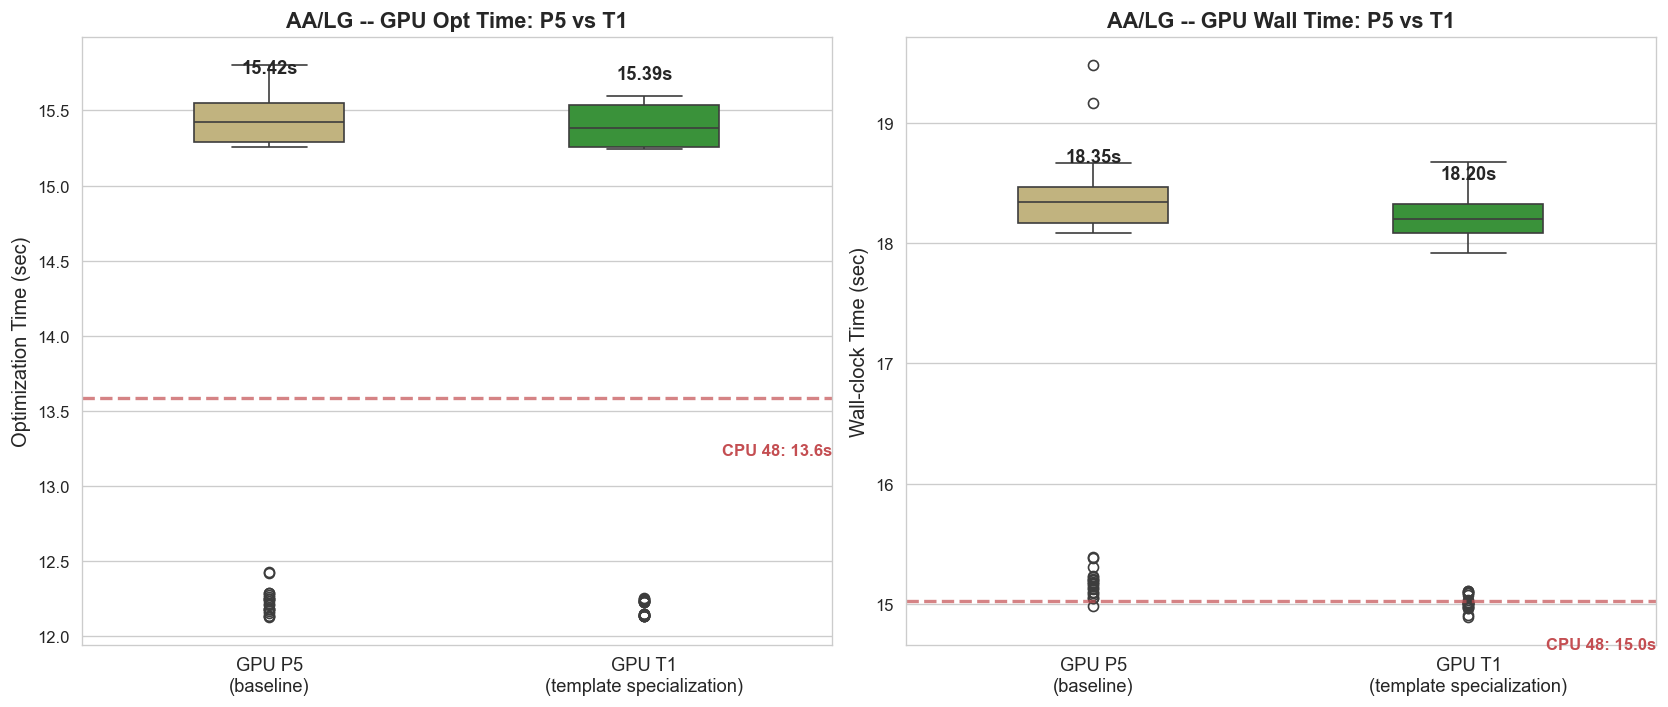

Saved: gpu_p5_vs_t1_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/4095650659.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/4095650659.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(p_labels, fontsize=11)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/4095650659.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/4095650659.py:36: UserWarning: set_tick

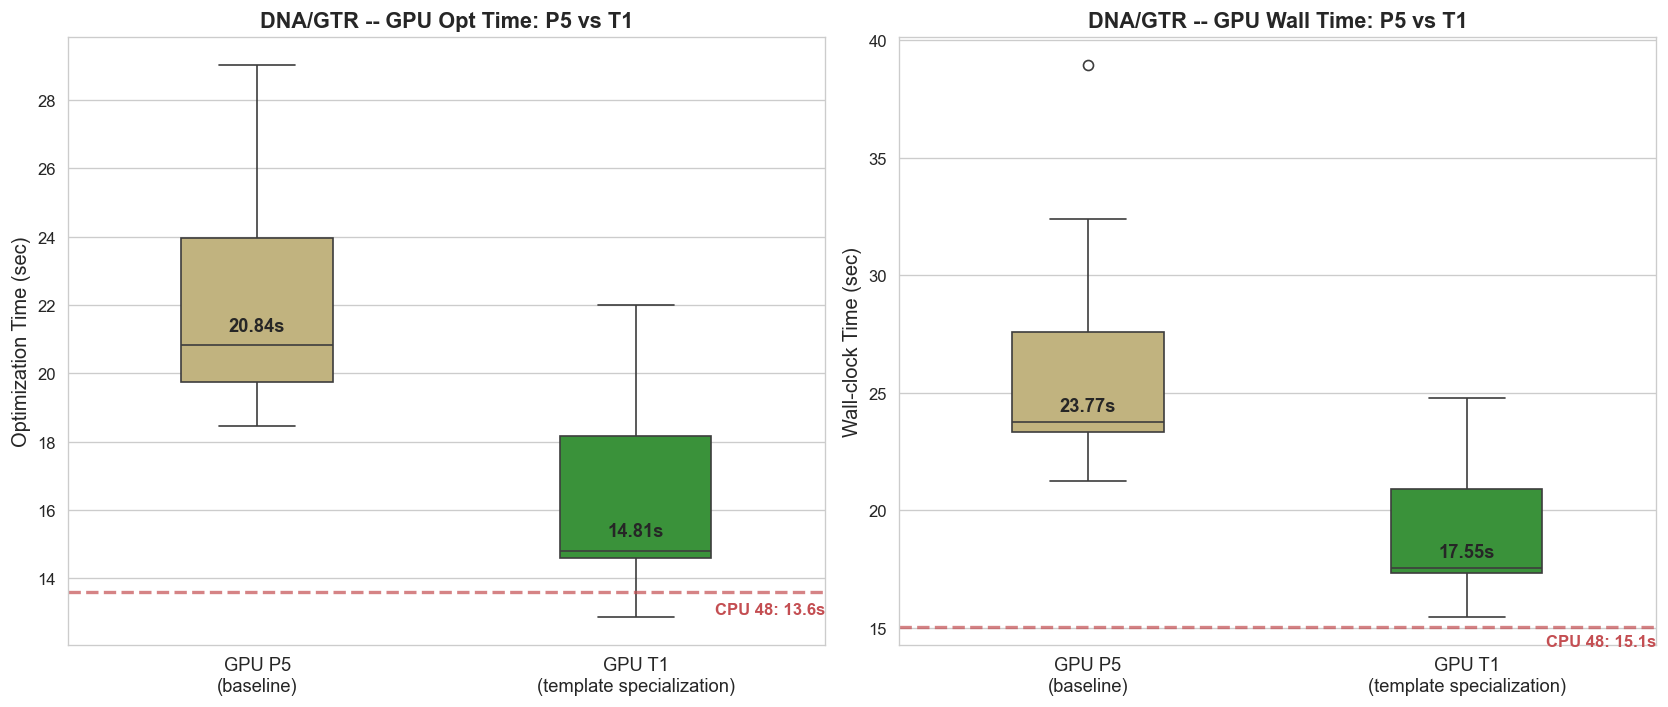

Saved: gpu_p5_vs_t1_DNA_GTR.png


In [7]:
gpu_order = ['GPU_P5', 'GPU_T1']
gpu_labels = ['GPU P5\n(baseline)', 'GPU T1\n(template specialization)']
gpu_colors = ['#CCB974', '#2ca02c']

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model) &
               df['backend'].isin(gpu_order)]
    present = [b for b in gpu_order if b in subset['backend'].unique()]
    p_colors = [gpu_colors[gpu_order.index(b)] for b in present]
    p_labels = [gpu_labels[gpu_order.index(b)] for b in present]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: opt_time
    sns.boxplot(data=subset, x='backend', y='opt_time',
               order=present, palette=p_colors, ax=ax1, width=0.4)
    ax1.set_xticklabels(p_labels, fontsize=11)
    ax1.set_ylabel('Optimization Time (sec)', fontsize=12)
    ax1.set_xlabel('')
    ax1.set_title(f'{data_type}/{model} -- GPU Opt Time: P5 vs T1', fontsize=13, fontweight='bold')
    medians = subset.groupby('backend')['opt_time'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax1.text(i, medians[b] + 0.3, f'{medians[b]:.2f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=11)
    cpu48_opt = df[(df['data_type'] == data_type) & (df['model'] == model) & 
                   (df['backend'] == 'OMP_48')]['opt_time'].median()
    if not np.isnan(cpu48_opt):
        ax1.axhline(y=cpu48_opt, color='#C44E52', linestyle='--', alpha=0.7, linewidth=2)
        ax1.text(len(present) - 0.5, cpu48_opt - 0.3, f'CPU 48: {cpu48_opt:.1f}s',
               fontsize=10, color='#C44E52', fontweight='bold', ha='right', va='top')
    
    # Right: walltime
    sns.boxplot(data=subset, x='backend', y='walltime',
               order=present, palette=p_colors, ax=ax2, width=0.4)
    ax2.set_xticklabels(p_labels, fontsize=11)
    ax2.set_ylabel('Wall-clock Time (sec)', fontsize=12)
    ax2.set_xlabel('')
    ax2.set_title(f'{data_type}/{model} -- GPU Wall Time: P5 vs T1', fontsize=13, fontweight='bold')
    medians_wt = subset.groupby('backend')['walltime'].median()
    for i, b in enumerate(present):
        if b in medians_wt.index:
            ax2.text(i, medians_wt[b] + 0.3, f'{medians_wt[b]:.2f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=11)
    cpu48_wt = df[(df['data_type'] == data_type) & (df['model'] == model) & 
                  (df['backend'] == 'OMP_48')]['walltime'].median()
    if not np.isnan(cpu48_wt):
        ax2.axhline(y=cpu48_wt, color='#C44E52', linestyle='--', alpha=0.7, linewidth=2)
        ax2.text(len(present) - 0.5, cpu48_wt - 0.3, f'CPU 48: {cpu48_wt:.1f}s',
               fontsize=10, color='#C44E52', fontweight='bold', ha='right', va='top')
    
    plt.tight_layout()
    fname = f'gpu_p5_vs_t1_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 5. Per-Tree Opt Time Comparison

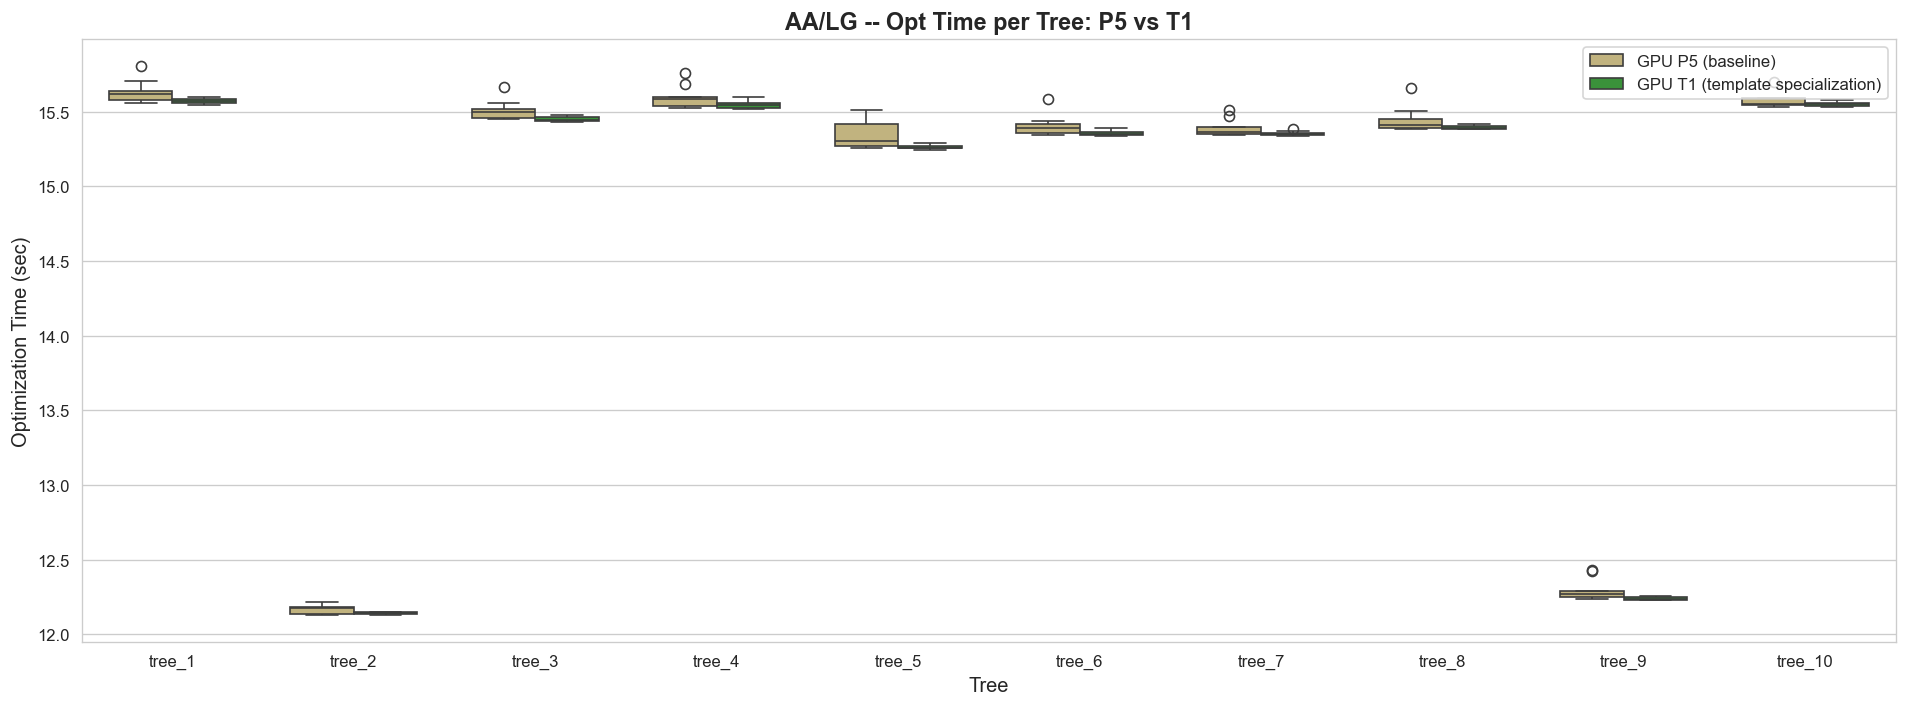

Saved: opt_per_tree_AA_LG.png


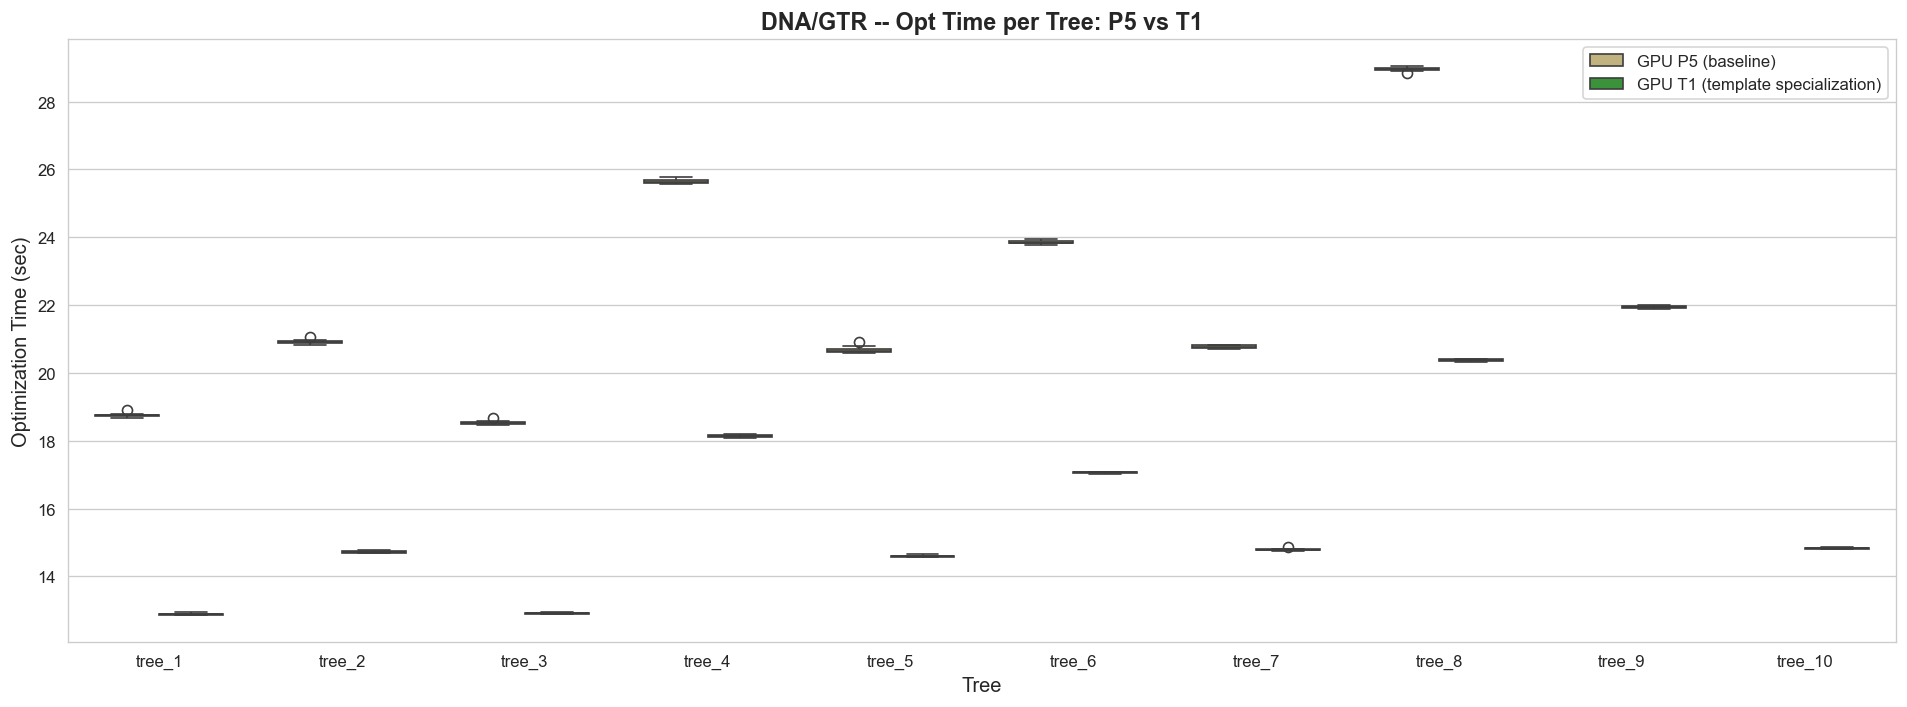

Saved: opt_per_tree_DNA_GTR.png


In [8]:
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model) &
               df['backend'].isin(['GPU_P5', 'GPU_T1'])]
    if subset.empty: continue
    trees = sorted(subset['tree'].unique(), key=lambda x: int(x.split('_')[1]))
    
    fig, ax = plt.subplots(figsize=(16, 6))
    sns.boxplot(data=subset, x='tree', y='opt_time', hue='backend',
               order=trees, hue_order=['GPU_P5', 'GPU_T1'],
               palette=['#CCB974', '#2ca02c'],
               ax=ax, width=0.7)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['GPU P5 (baseline)', 'GPU T1 (template specialization)'],
             fontsize=10, loc='upper right')
    ax.set_xlabel('Tree', fontsize=12)
    ax.set_ylabel('Optimization Time (sec)', fontsize=12)
    ax.set_title(f'{data_type}/{model} -- Opt Time per Tree: P5 vs T1',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = f'opt_per_tree_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

In [9]:
# Per-tree improvement table
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    print(f'\n=== {data_type}/{model} Per-Tree Opt Time (median) ===')
    subset = df[(df['data_type'] == data_type) & (df['model'] == model) &
               df['backend'].isin(['GPU_P5', 'GPU_T1'])]
    trees = sorted(subset['tree'].unique(), key=lambda x: int(x.split('_')[1]))
    
    rows = []
    for tree in trees:
        p5_med = subset[(subset['tree'] == tree) & (subset['backend'] == 'GPU_P5')]['opt_time'].median()
        t1_med = subset[(subset['tree'] == tree) & (subset['backend'] == 'GPU_T1')]['opt_time'].median()
        if not np.isnan(p5_med) and not np.isnan(t1_med):
            change_s = t1_med - p5_med
            change_pct = (t1_med - p5_med) / p5_med * 100
            rows.append({'tree': tree, 'P5': p5_med, 'T1': t1_med,
                        'delta_s': change_s, 'delta_pct': change_pct})
    
    tree_df = pd.DataFrame(rows)
    tree_df = tree_df.round(3)
    display(tree_df)
    print(f'Mean change: {tree_df["delta_pct"].mean():.1f}%')


=== AA/LG Per-Tree Opt Time (median) ===


,tree,P5,T1,delta_s,delta_pct
0,tree_1,15.616,15.570,-0.046,-0.291
1,tree_2,12.174,12.140,-0.034,-0.275
2,tree_3,15.500,15.445,-0.055,-0.355
3,tree_4,15.588,15.544,-0.044,-0.282
4,tree_5,15.305,15.259,-0.046,-0.304
5,tree_6,15.394,15.354,-0.039,-0.253
6,tree_7,15.366,15.350,-0.016,-0.107
7,tree_8,15.411,15.394,-0.018,-0.114
8,tree_9,12.272,12.237,-0.034,-0.281
9,tree_10,15.553,15.550,-0.003,-0.019


Mean change: -0.2%

=== DNA/GTR Per-Tree Opt Time (median) ===


,tree,P5,T1,delta_s,delta_pct
0,tree_1,18.745,12.894,-5.850,-31.211
1,tree_2,20.910,14.730,-6.180,-29.557
2,tree_3,18.528,12.922,-5.605,-30.254
3,tree_4,25.642,18.140,-7.502,-29.257
4,tree_5,20.661,14.596,-6.066,-29.357
5,tree_6,23.842,17.069,-6.773,-28.407
6,tree_7,20.777,14.791,-5.986,-28.811
7,tree_8,28.964,20.370,-8.593,-29.670


Mean change: -29.6%


## 6. All Backends — Full Comparison

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/4216312061.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/4216312061.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/4216312061.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/42163

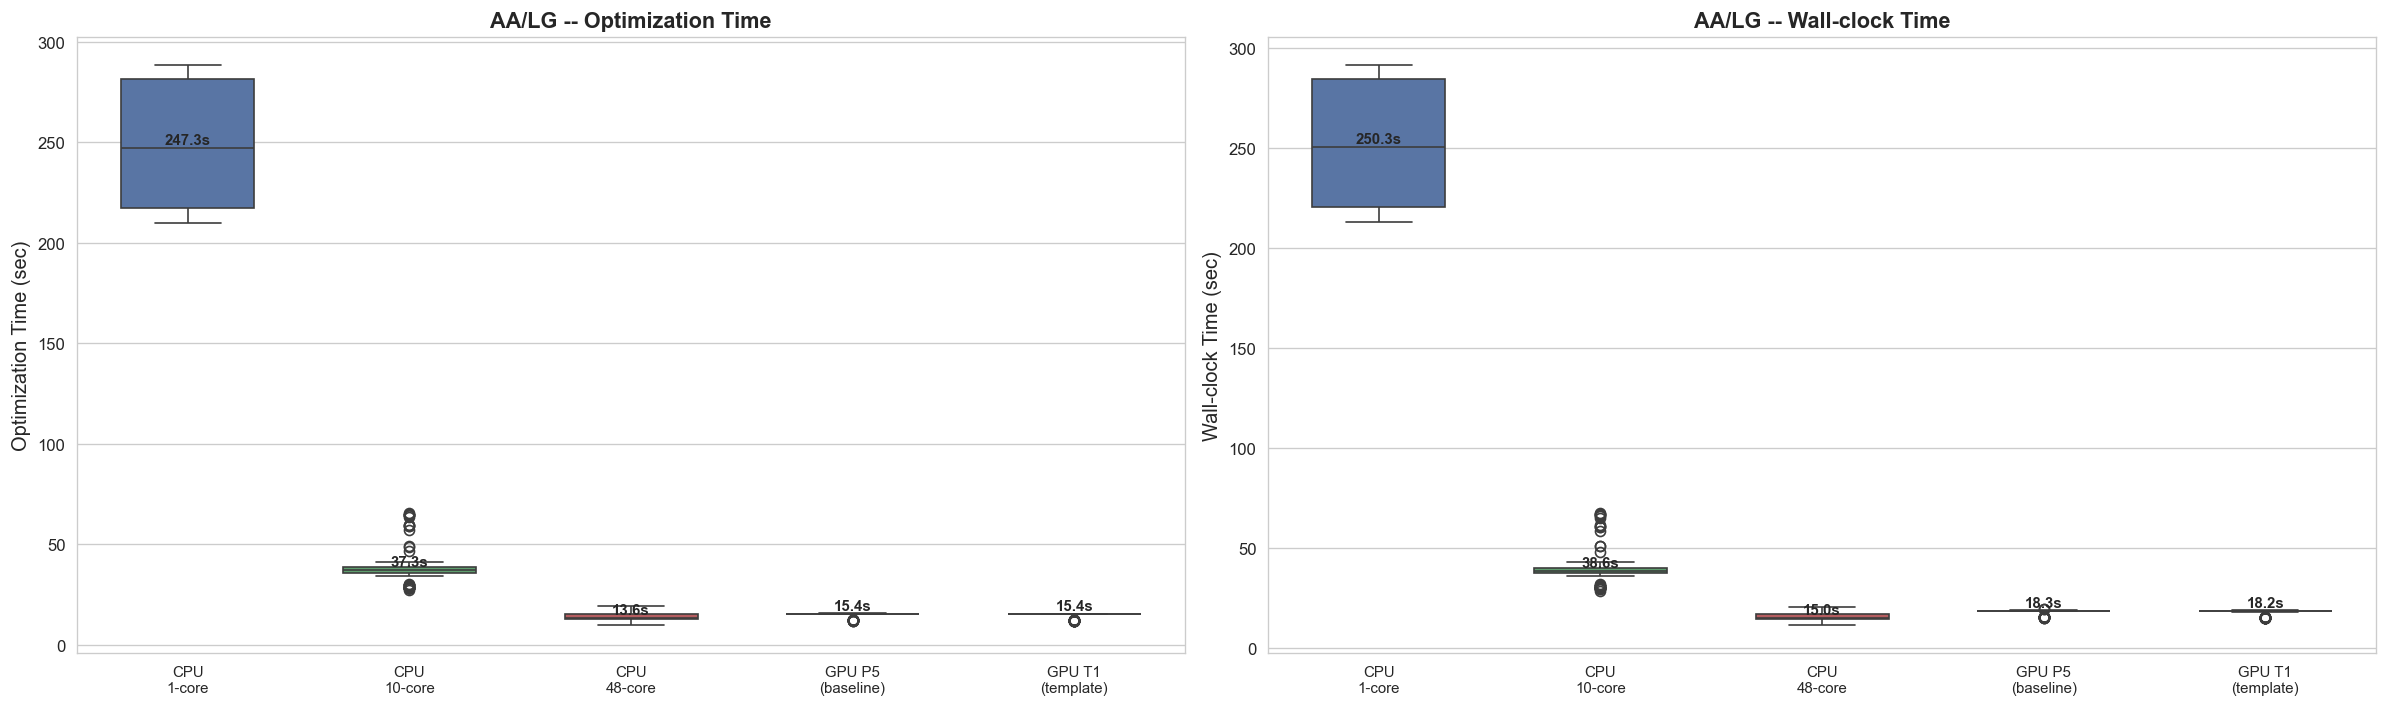

Saved: all_backends_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/4216312061.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/4216312061.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/4216312061.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_92286/42163

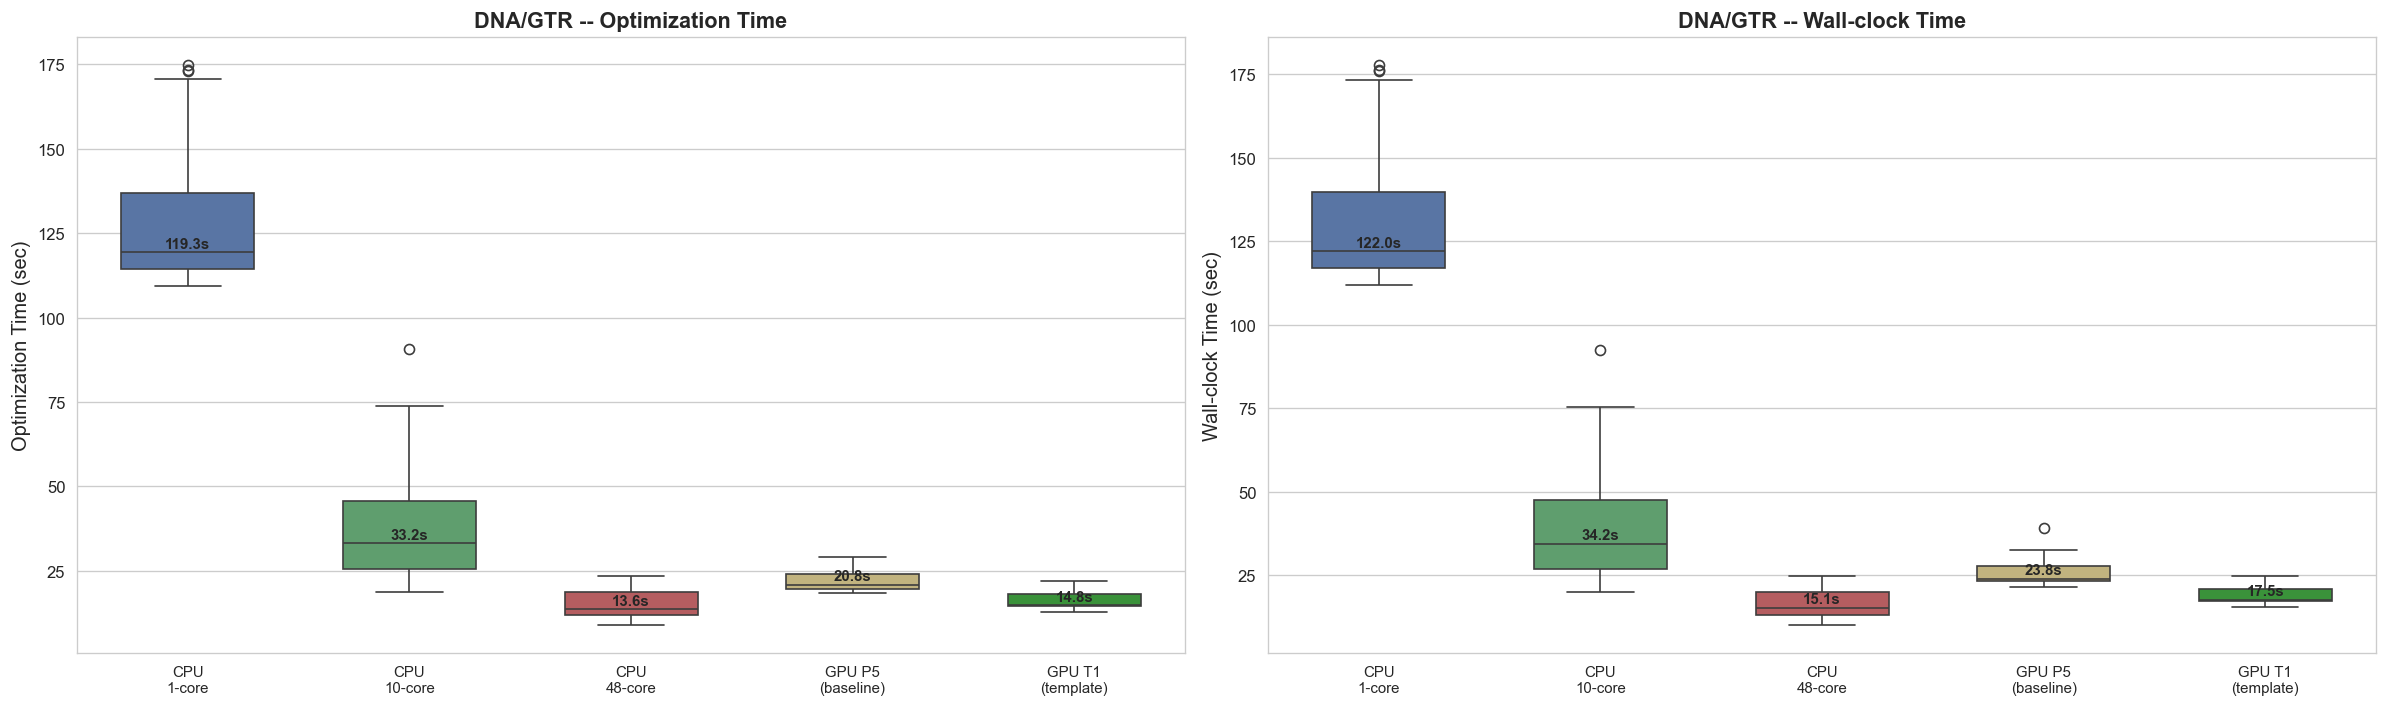

Saved: all_backends_DNA_GTR.png


In [10]:
backend_order = ['VANILA', 'OMP_10', 'OMP_48', 'GPU_P5', 'GPU_T1']
backend_colors = {
    'VANILA': '#4C72B0', 'OMP_10': '#55A868', 'OMP_48': '#C44E52',
    'GPU_P5': '#CCB974', 'GPU_T1': '#2ca02c'
}
backend_labels = {
    'VANILA': 'CPU\n1-core', 'OMP_10': 'CPU\n10-core', 'OMP_48': 'CPU\n48-core',
    'GPU_P5': 'GPU P5\n(baseline)', 'GPU_T1': 'GPU T1\n(template)'
}

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model)]
    present = [b for b in backend_order if b in subset['backend'].unique()]
    palette = [backend_colors[b] for b in present]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
    
    sns.boxplot(data=subset, x='backend', y='opt_time',
               order=present, palette=palette, ax=ax1, width=0.6)
    ax1.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)
    ax1.set_ylabel('Optimization Time (sec)', fontsize=12)
    ax1.set_xlabel('')
    ax1.set_title(f'{data_type}/{model} -- Optimization Time', fontsize=13, fontweight='bold')
    medians = subset.groupby('backend')['opt_time'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax1.text(i, medians[b] + 0.5, f'{medians[b]:.1f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    sns.boxplot(data=subset, x='backend', y='walltime',
               order=present, palette=palette, ax=ax2, width=0.6)
    ax2.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)
    ax2.set_ylabel('Wall-clock Time (sec)', fontsize=12)
    ax2.set_xlabel('')
    ax2.set_title(f'{data_type}/{model} -- Wall-clock Time', fontsize=13, fontweight='bold')
    medians_wt = subset.groupby('backend')['walltime'].median()
    for i, b in enumerate(present):
        if b in medians_wt.index:
            ax2.text(i, medians_wt[b] + 0.5, f'{medians_wt[b]:.1f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    fname = f'all_backends_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 7. Final Summary + Conclusions

In [11]:
final = df.groupby(['data_type', 'model', 'backend']).agg(
    walltime_median=('walltime', 'median'),
    opt_time_median=('opt_time', 'median'),
    overhead_median=('overhead', 'median'),
    mean_logl=('log_likelihood', 'mean'),
    n_runs=('walltime', 'count')
).round(2).reset_index()

for ref_name, ref_backend in [('vs_cpu48', 'OMP_48'), ('vs_P5', 'GPU_P5')]:
    ref = final[final['backend'] == ref_backend][['data_type', 'model', 'opt_time_median']].rename(
        columns={'opt_time_median': 'ref'})
    final = final.merge(ref, on=['data_type', 'model'], how='left')
    final[f'opt_speedup_{ref_name}'] = (final['ref'] / final['opt_time_median']).round(3)
    final.drop(columns='ref', inplace=True)

final.to_csv(SAVE_DIR / 'final_summary.csv', index=False)
display(final)

,data_type,model,backend,walltime_median,opt_time_median,overhead_median,mean_logl,n_runs,opt_speedup_vs_cpu48,opt_speedup_vs_P5
0,AA,LG,GPU_P5,18.35,15.42,2.91,-86307686.71,95,0.881,1.000
1,AA,LG,GPU_T1,18.20,15.39,2.82,-86328013.80,100,0.883,1.002
2,AA,LG,OMP_10,38.56,37.32,1.28,-86328013.80,100,0.364,0.413
3,AA,LG,OMP_48,15.02,13.59,1.39,-86328013.80,100,1.000,1.135
4,AA,LG,VANILA,250.29,247.28,2.99,-89703067.78,20,0.055,0.062
5,DNA,GTR,GPU_P5,23.77,20.84,2.87,-66545174.85,79,0.653,1.000
6,DNA,GTR,GPU_T1,17.55,14.81,2.74,-67389524.67,97,0.919,1.407
7,DNA,GTR,OMP_10,34.24,33.17,1.08,-67437010.89,100,0.410,0.628
8,DNA,GTR,OMP_48,15.05,13.61,1.10,-67437010.89,100,1.000,1.531
9,DNA,GTR,VANILA,122.00,119.26,2.69,-66533394.68,40,0.114,0.175


In [12]:
print('=' * 80)
print('CONCLUSIONS -- T1 Template Specialization for OpenACC GPU Kernels')
print('=' * 80)

# Correctness
range_check = df.groupby(['data_type', 'model', 'tree']).agg(
    logl_range=('log_likelihood', lambda x: x.max() - x.min())
).reset_index()
max_range = range_check['logl_range'].max()
print(f'\nLIKELIHOOD VERIFICATION:')
print(f'  Max log-likelihood range across any tree: {max_range}')
if max_range < 0.01:
    print('  \u2705 ALL BACKENDS PRODUCE IDENTICAL LOG-LIKELIHOODS.')
    print('  \u2705 T1 IS CORRECT.')
else:
    print('  \u274c WARNING: Some trees have likelihood mismatches!')

# Underflow check
total_underflow = df_t1['n_underflow'].sum() if 'n_underflow' in df_t1.columns else -1
print(f'\nNUMERICAL STABILITY:')
print(f'  Total underflow warnings: {total_underflow}')
if total_underflow == 0:
    print('  \u2705 No numerical underflow — T1 is numerically stable.')

# Performance
print(f'\nPERFORMANCE (opt_time medians):')
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    p5_opt = df[(df['data_type'] == data_type) & (df['backend'] == 'GPU_P5')]['opt_time'].median()
    t1_opt = df[(df['data_type'] == data_type) & (df['backend'] == 'GPU_T1')]['opt_time'].median()
    cpu48_opt = df[(df['data_type'] == data_type) & (df['backend'] == 'OMP_48')]['opt_time'].median()
    
    if not np.isnan(p5_opt) and not np.isnan(t1_opt):
        change = (t1_opt - p5_opt) / p5_opt * 100
        vs_cpu = t1_opt / cpu48_opt
        print(f'  {data_type}/{model}: P5={p5_opt:.2f}s -> T1={t1_opt:.2f}s '
              f'({change:+.1f}%) '
              f'  vs CPU48: {vs_cpu:.2f}x')

print(f'\n{"=" * 80}')
print('T1 templates kernel functions on <int NSTATES> (4=DNA, 20=AA, 0=generic).')
print('DNA (NSTATES=4): outer-loop vectorization, 100% vector utilization (was 12.5%).')
print('AA (NSTATES=20): compile-time loop unrolling + div/mod optimization.')
print('Batched kernels: compile-time inner loop unrolling for all traversals.')

CONCLUSIONS -- T1 Template Specialization for OpenACC GPU Kernels

LIKELIHOOD VERIFICATION:
  Max log-likelihood range across any tree: 0.0
  ✅ ALL BACKENDS PRODUCE IDENTICAL LOG-LIKELIHOODS.
  ✅ T1 IS CORRECT.

NUMERICAL STABILITY:
  Total underflow warnings: 0
  ✅ No numerical underflow — T1 is numerically stable.

PERFORMANCE (opt_time medians):
  AA/LG: P5=15.42s -> T1=15.39s (-0.2%)   vs CPU48: 1.13x
  DNA/GTR: P5=20.84s -> T1=14.81s (-28.9%)   vs CPU48: 1.09x

T1 templates kernel functions on <int NSTATES> (4=DNA, 20=AA, 0=generic).
DNA (NSTATES=4): outer-loop vectorization, 100% vector utilization (was 12.5%).
AA (NSTATES=20): compile-time loop unrolling + div/mod optimization.
Batched kernels: compile-time inner loop unrolling for all traversals.
